# Benchmarking TabM Against Classical ML Models for Network Intrusion Detection

**Dataset:** NSL-KDD (a cleaned version of the KDD Cup 1999 dataset)  
**Task:** 5-class multiclass classification — Normal, DoS, Probe, R2L, U2R  
**Models:** TabM (ICLR 2025), MLP, XGBoost, Random Forest

## Background

Intrusion Detection Systems (IDS) monitor network traffic and flag malicious activity. Traditional 
IDS rely on hand-crafted rules; ML-based IDS learn attack patterns directly from labeled network 
connection records.

### Why TabM?

**TabM** (Tabular Model with Multiple predictions) is a deep learning architecture for tabular data 
published at ICLR 2025 by Yandex Research. It extends a standard MLP by representing an ensemble 
of *k* sub-models using **BatchEnsemble** — a parameter-efficient technique that tiles a shared 
weight matrix with learnable per-sub-model scaling vectors. Each forward pass produces *k* logit 
vectors that are averaged at inference time.

This project provides the **first benchmark of TabM on a cybersecurity / IDS dataset**, comparing 
it against the strongest classical baselines (XGBoost, Random Forest) and a structurally matched 
MLP.

### NSL-KDD Dataset

NSL-KDD contains network connection records with 41 features (3 categorical, 38 numeric) and a 
string attack label. We map all attack labels to 5 integer classes:

| Class | Name   | Description                              |
|-------|--------|------------------------------------------|
| 0     | Normal | Legitimate traffic                       |
| 1     | DoS    | Denial of Service (resource exhaustion)  |
| 2     | Probe  | Reconnaissance / port scanning           |
| 3     | R2L    | Remote to Local (unauthorised access)    |
| 4     | U2R    | User to Root (privilege escalation)      |

**Download:** https://www.unb.ca/cic/datasets/nsl.html  
Place `KDDTrain+.txt` and `KDDTest+.txt` in the `data/` folder before running.

## Cell 1 — Environment Setup

Set all random seeds before importing any ML library so that results are fully reproducible 
across runs. Then ensure the `results/` directory exists for saving outputs.

In [3]:
import os
import random
import numpy as np
import torch
import joblib

# Must be set before ANY C extension (sklearn, xgboost, torch) is imported.
# On macOS, sklearn and XGBoost each ship their own libomp; loading both in
# the same process aborts with "OMP: Error #15" which kills the Jupyter kernel.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # allow duplicate libomp — critical on macOS

# Global random seed — set before any library that uses randomness is imported
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs('results', exist_ok=True)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Device          : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"KMP_DUPLICATE_LIB_OK: {os.environ['KMP_DUPLICATE_LIB_OK']}")

PyTorch version : 2.11.0
CUDA available  : False
Device          : cpu
KMP_DUPLICATE_LIB_OK: TRUE


## Cell 2 — Data Preprocessing

The `load_and_preprocess` function:
1. Reads both CSV files (no header — column names are assigned manually)
2. Drops the `difficulty` score column (a meta-label, not a network feature)
3. Maps all 39 known attack label strings to 5 integer class indices
4. Label-encodes the 3 categorical features, fitting on train+test to avoid unseen-category errors
5. Standardises all 41 features using `StandardScaler` **fit on training data only** (prevents data leakage)

> **No oversampling or undersampling is applied.** Training on the naturally imbalanced dataset 
> reflects real-world IDS conditions and tests each model's intrinsic ability to handle class skew.

In [4]:
from src.preprocess import load_and_preprocess

print("Loading and preprocessing NSL-KDD...")
X_train, y_train, X_test, y_test = load_and_preprocess(
    train_path='data/KDDTrain+.txt',
    test_path='data/KDDTest+.txt',
)

Loading and preprocessing NSL-KDD...

Training class distribution:
  Normal  :  67343  (53.5%)
  DoS     :  45927  (36.5%)
  Probe   :  11656  (9.3%)
  R2L     :    995  (0.8%)
  U2R     :     52  (0.0%)

Test class distribution:
  Normal  :   9711  (43.1%)
  DoS     :   7460  (33.1%)
  Probe   :   2421  (10.7%)
  R2L     :   2885  (12.8%)
  U2R     :     67  (0.3%)

X_train: (125973, 122)  |  X_test: (22544, 122)  |  n_features (after OHE): 122


## Cell 3 — Train MLP Baseline

The sklearn `MLPClassifier` is configured with **the same depth and width as TabM's backbone** 
(3 hidden layers × 256 units, ReLU, Adam, lr=1e-3, batch_size=256, 50 epochs).  

This structural match is intentional: any accuracy gap between MLP and TabM directly reflects 
the benefit of BatchEnsemble prediction averaging, not additional model capacity.

In [5]:
from src.train_baselines import train_mlp

print("Training MLP...")
mlp_model, mlp_preds = train_mlp(X_train, y_train, X_test)
print("MLP training complete.")

Training MLP...
[LOG] train_mlp — start  (mem=394 MB)
[LOG] train_mlp — calling fit()  (mem=394 MB)
Iteration 1, loss = 0.06323019
Iteration 2, loss = 0.02382174
Iteration 3, loss = 0.01921994
Iteration 4, loss = 0.01603175
Iteration 5, loss = 0.01484187
Iteration 6, loss = 0.01418737
Iteration 7, loss = 0.01236923
Iteration 8, loss = 0.01192302
Iteration 9, loss = 0.01106039
Iteration 10, loss = 0.01002191
Iteration 11, loss = 0.01025258
Iteration 12, loss = 0.00981344
Iteration 13, loss = 0.00948261
Iteration 14, loss = 0.00915249
Iteration 15, loss = 0.01099621
Iteration 16, loss = 0.00885253
Iteration 17, loss = 0.00834440
Iteration 18, loss = 0.00787027
Iteration 19, loss = 0.00761232
Iteration 20, loss = 0.00771297
Iteration 21, loss = 0.00857962
Iteration 22, loss = 0.00763294
Iteration 23, loss = 0.00859299
Iteration 24, loss = 0.00772891
Iteration 25, loss = 0.00718203
Iteration 26, loss = 0.00697074
Iteration 27, loss = 0.00711522
Iteration 28, loss = 0.00720727
Iteration 29,

/Users/spartan/Desktop/CS 271/CS271_Project/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


## Cell 4 — Train XGBoost Baseline

XGBoost with 100 gradient boosted trees is typically the strongest classical tabular baseline.  
Settings:
- `max_depth=6` limits tree depth to prevent overfitting on the dominant DoS class
- `subsample=0.8` and `colsample_bytree=0.8` add stochasticity similar to Random Forest
- `eval_metric='mlogloss'` measures multiclass log-loss (consistent with our cross-entropy training of TabM/MLP)

In [6]:
import importlib
import src.train_baselines
importlib.reload(src.train_baselines)
from src.train_baselines import train_xgboost

print("Training XGBoost...")
xgb_model, xgb_preds = train_xgboost(X_train, y_train, X_test)
print("XGBoost training complete.")

Training XGBoost...
[LOG] train_xgboost — start  (mem=448 MB)
[LOG]   OMP_NUM_THREADS=1  KMP_DUPLICATE_LIB_OK=TRUE  (mem=448 MB)
[LOG]   X_train shape=(125973, 122)  X_test shape=(22544, 122)  (mem=448 MB)
[LOG] train_xgboost — creating XGBClassifier  (mem=448 MB)
[LOG] train_xgboost — calling fit() with sample_weight  (mem=449 MB)
[LOG]   XGBoost round 40/400  (mem=486 MB)
[LOG]   XGBoost round 80/400  (mem=466 MB)
[LOG]   XGBoost round 120/400  (mem=428 MB)
[LOG]   XGBoost round 160/400  (mem=424 MB)
[LOG]   XGBoost round 200/400  (mem=425 MB)
[LOG]   XGBoost round 240/400  (mem=358 MB)
[LOG]   XGBoost round 280/400  (mem=356 MB)
[LOG]   XGBoost round 320/400  (mem=306 MB)
[LOG]   XGBoost round 360/400  (mem=162 MB)
[LOG]   XGBoost round 400/400  (mem=155 MB)
[LOG] train_xgboost — fit() done, calling predict()  (mem=178 MB)
[LOG] train_xgboost — predict() done  (mem=193 MB)
[LOG] train_xgboost — returning  (mem=384 MB)
XGBoost training complete.


## Cell 5 — Train Random Forest Baseline

Random Forest with 200 fully-grown decision trees (unpruned, `max_depth=None`).  
Majority voting across 200 trees provides strong variance reduction, making it robust to the 
noisy and imbalanced NSL-KDD class distribution.

In [7]:
from src.train_baselines import train_random_forest

print("Training Random Forest...")
rf_model, rf_preds = train_random_forest(X_train, y_train, X_test)
print("Random Forest training complete.")

Training Random Forest...
[LOG] train_random_forest — start  (mem=385 MB)
[LOG]   X_train shape=(125973, 122)  X_test shape=(22544, 122)  (mem=385 MB)
[LOG] train_random_forest — calling fit()  (mem=385 MB)
[LOG] train_random_forest — fit() done, calling predict()  (mem=464 MB)
[LOG] train_random_forest — predict() done, returning  (mem=465 MB)
Random Forest training complete.


## Cell 6 — Train TabM

### Architecture

TabM is constructed with:

| Hyperparameter | Value | Rationale |
|---|---|---|
| `n_num_features` | 41 | All 41 NSL-KDD features (categorical columns are already integer-encoded) |
| `n_blocks` | 3 | Depth matching the MLP baseline |
| `d_block` | 256 | Width matching the MLP baseline |
| `dropout` | 0.1 | Mild regularisation |
| `k` | 16 | Ensemble of 16 sub-models (paper default is 32; 16 reduces memory) |
| `arch_type` | `'tabm'` | Full BatchEnsemble (vs lighter `'tabm-mini'`) |

### Forward pass

During training, `model(x_num=X_b)` returns shape `(batch, k=16, 5)`.  
We average across the `k` dimension to get `(batch, 5)` logits before computing cross-entropy loss.  
The same averaging is used at inference — this is the key mechanism that gives TabM an ensemble benefit 
at the cost of a single training run.

### Optimizer

AdamW with `lr=1e-3`, `weight_decay=1e-5` — standard for tabular deep learning models.

In [8]:
from src.train_tabm import train_tabm

print("Training TabM...")
tabm_model, tabm_preds, tabm_losses = train_tabm(X_train, y_train, X_test, y_test)

Training TabM...
  TabM training on: cpu
  Total TabM parameters: 217,584
  Class weights (capped): {0: '0.37', 1: '0.55', 2: '2.16', 3: '18.71', 4: '18.71'}
  Epoch  10/50 — loss: 0.0356 | train acc: 0.9856 | lr: 9.05e-04
  Epoch  20/50 — loss: 0.0243 | train acc: 0.9849 | lr: 6.55e-04
  Epoch  30/50 — loss: 0.0153 | train acc: 0.9944 | lr: 3.45e-04
  Epoch  40/50 — loss: 0.0110 | train acc: 0.9963 | lr: 9.55e-05
  Epoch  50/50 — loss: 0.0098 | train acc: 0.9965 | lr: 0.00e+00
  TabM model weights saved to results/tabm_model.pt


## Cell 7 — Save Baseline Models

Pickle the three sklearn/XGBoost models to disk using `joblib` so they can be 
reloaded for inference without retraining.  
The TabM weights were already saved inside `train_tabm` as `results/tabm_model.pt`.

In [9]:
joblib.dump(mlp_model, 'results/mlp_model.joblib')

# Strip any unpicklable TrainingCallback instances before serialising.
# Callbacks hold internal C state; the trained booster is unaffected.
xgb_model.set_params(callbacks=None)
joblib.dump(xgb_model, 'results/xgb_model.joblib')

joblib.dump(rf_model,  'results/rf_model.joblib')
print("Baseline models saved to results/")

Baseline models saved to results/


## Cell 7b — Inference timing (test set)

**Inference** = time to classify all `X_test` rows (22,544 connections) using already-trained models. Training time is **not** included.

- **No retraining needed** if models are in memory from the cells above, or saved under `results/*.joblib` and `results/tabm_model.pt`.
- Run this cell after training (or after Cell 7 save). Takes a few seconds.
- Results are written to `results/inference_timing.csv` for the report.

In [15]:
from src.benchmark_inference import benchmark_inference

# Uses in-memory models when available; otherwise loads from results/
benchmark_inference(
    X_test,
    mlp_model=mlp_model,
    xgb_model=xgb_model,
    rf_model=rf_model,
    tabm_model=tabm_model,
    n_repeat=5,
)

Inference timing saved to results/inference_timing.csv

       Model  n_test  n_features  total_s_mean  total_s_std  ms_per_sample  samples_per_s
         MLP   22544         122        0.0308       0.0079         0.0014       732990.4
     XGBoost   22544         122        0.3932       0.0394         0.0174        57331.1
RandomForest   22544         122        0.2113       0.0029         0.0094       106697.4
        TabM   22544         122        0.9609       0.1106         0.0426        23462.5


,Model,n_test,n_features,total_s_mean,total_s_std,ms_per_sample,samples_per_s
0,MLP,22544,122,0.0308,0.0079,0.0014,732990.4
1,XGBoost,22544,122,0.3932,0.0394,0.0174,57331.1
2,RandomForest,22544,122,0.2113,0.0029,0.0094,106697.4
3,TabM,22544,122,0.9609,0.1106,0.0426,23462.5


## Cell 8 — Evaluate All Models

We report four scalar metrics for each model:

| Metric | Averaging | Why |
|--------|-----------|-----|
| Accuracy | — | Overall fraction correctly classified |
| Precision | Macro | Unweighted average over all 5 classes — penalises ignoring rare classes |
| Recall | Macro | Same — measures how well each class is detected |
| F1 | Macro | Harmonic mean of macro precision and recall |

**Why macro?** With `weighted` averaging, the model can score high by excelling only on DoS 
(the majority class). Macro averaging assigns equal weight to all 5 classes, including the 
critical but rare U2R class, which reflects real IDS priorities.

`zero_division=0` silences division-by-zero warnings for classes that are never predicted.

In [10]:
from src.evaluate import evaluate_all

results = evaluate_all(
    y_test=y_test,
    predictions={
        'TabM':         tabm_preds,
        'MLP':          mlp_preds,
        'XGBoost':      xgb_preds,
        'RandomForest': rf_preds,
    },
)


Model: TabM
  Accuracy:  0.7808
  Precision: 0.7295 (macro)
  Recall:    0.6209 (macro)
  F1:        0.6054 (macro)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.95      0.80      9711
         DoS       0.95      0.83      0.89      7460
       Probe       0.75      0.76      0.75      2421
         R2L       0.94      0.12      0.21      2885
         U2R       0.31      0.45      0.37        67

    accuracy                           0.78     22544
   macro avg       0.73      0.62      0.61     22544
weighted avg       0.82      0.78      0.75     22544


Model: MLP
  Accuracy:  0.7638
  Precision: 0.8386 (macro)
  Recall:    0.5876 (macro)
  F1:        0.6116 (macro)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.68      0.93      0.79      9711
         DoS       0.96      0.83      0.89      7460
       Probe       0.69      0.72      0.70      2421
         R2L 

## Cell 9 — Summary Table

Display the CSV summary table inline for a quick side-by-side comparison.

In [11]:
import pandas as pd

summary_df = pd.read_csv('results/summary_metrics.csv')
print(summary_df.to_string(index=False))

       Model  Accuracy  Precision  Recall  F1_macro  F1_Normal  F1_DoS  F1_Probe  F1_R2L  F1_U2R
        TabM    0.7808     0.7295  0.6209    0.6054     0.8042  0.8891    0.7531  0.2148  0.3659
         MLP    0.7638     0.8386  0.5876    0.6116     0.7860  0.8914    0.7024  0.1309  0.5474
     XGBoost    0.7914     0.8343  0.5743    0.6070     0.8123  0.8982    0.7663  0.2361  0.3218
RandomForest    0.7358     0.7603  0.4728    0.4759     0.7684  0.8495    0.6963  0.0090  0.0563


## Cell 10 — Generate All Plots

The following plots are saved to `results/`:

| File | Description |
|------|-------------|
| `{Model}_confusion_matrix.png` | Row-normalised confusion matrix per model |
| `f1_comparison.png` | Per-class F1 bar chart — all models side-by-side |
| `overall_metrics_comparison.png` | Accuracy / Precision / Recall / F1 macro grouped bar chart |
| `tabm_training_loss.png` | TabM cross-entropy loss vs epoch |
| `xgb_feature_importance.png` | XGBoost top-20 features by gain |

Confusion matrices use row-normalisation (`normalize='true'`) so each row shows the 
recall for that class — this makes it easy to spot which attack type each model misclassifies.

In [12]:
from src.visualize import generate_all_plots

generate_all_plots(
    y_test=y_test,
    predictions=results['predictions'],
    all_metrics=results['metrics'],
    tabm_losses=tabm_losses,
    xgb_model=xgb_model,
)

  Saved: results/TabM_confusion_matrix.png
  Saved: results/MLP_confusion_matrix.png
  Saved: results/XGBoost_confusion_matrix.png
  Saved: results/RandomForest_confusion_matrix.png
  Saved: results/f1_comparison.png
  Saved: results/overall_metrics_comparison.png
  Saved: results/tabm_training_loss.png
  Saved: results/xgb_feature_importance.png

All plots saved to results/


## Cell 11 — Display Plots Inline

Render the saved figures directly in the notebook for convenience.

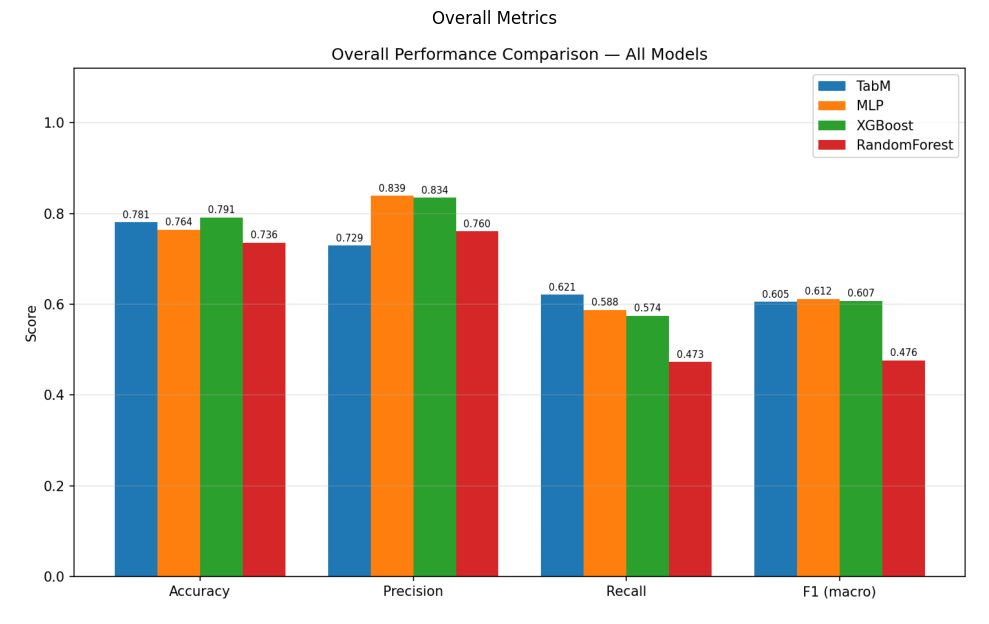

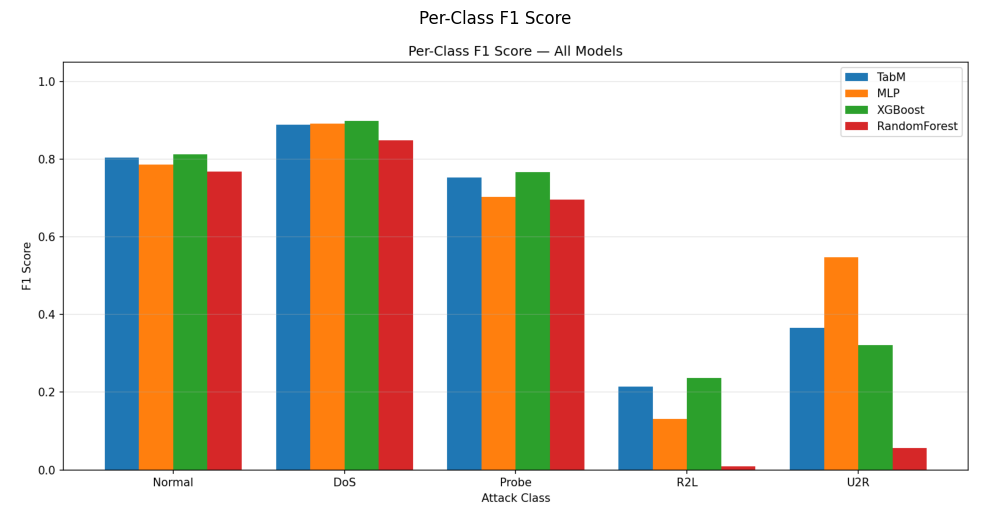

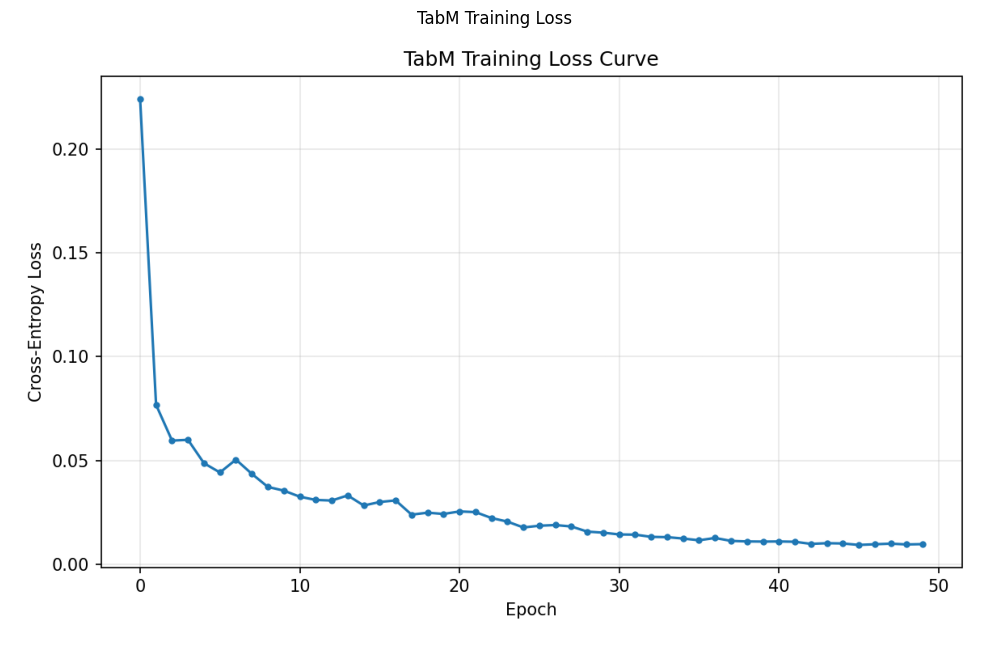

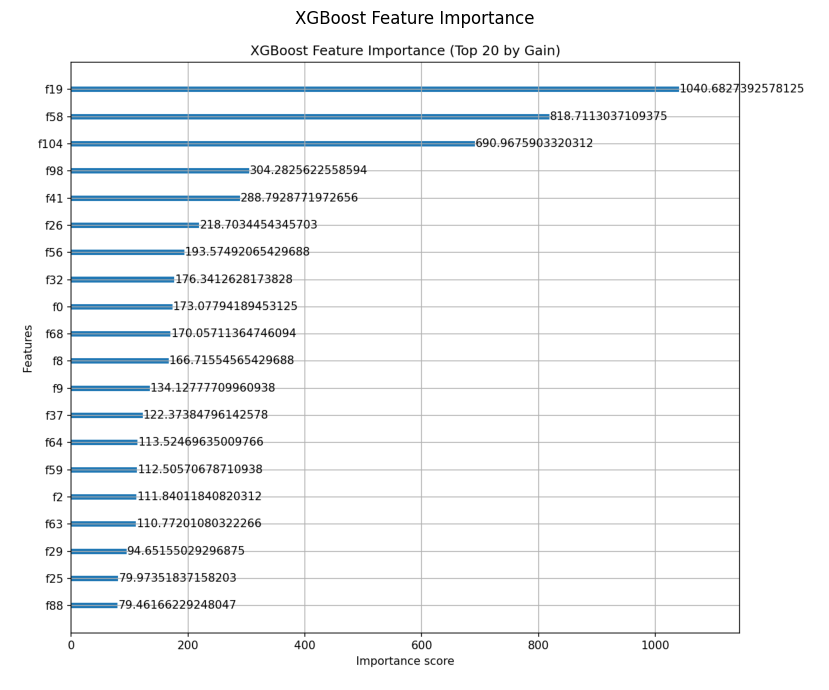

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(path, title=''):
    img = mpimg.imread(path)
    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

show_image('results/overall_metrics_comparison.png', 'Overall Metrics')
show_image('results/f1_comparison.png',              'Per-Class F1 Score')
show_image('results/tabm_training_loss.png',         'TabM Training Loss')
show_image('results/xgb_feature_importance.png',     'XGBoost Feature Importance')

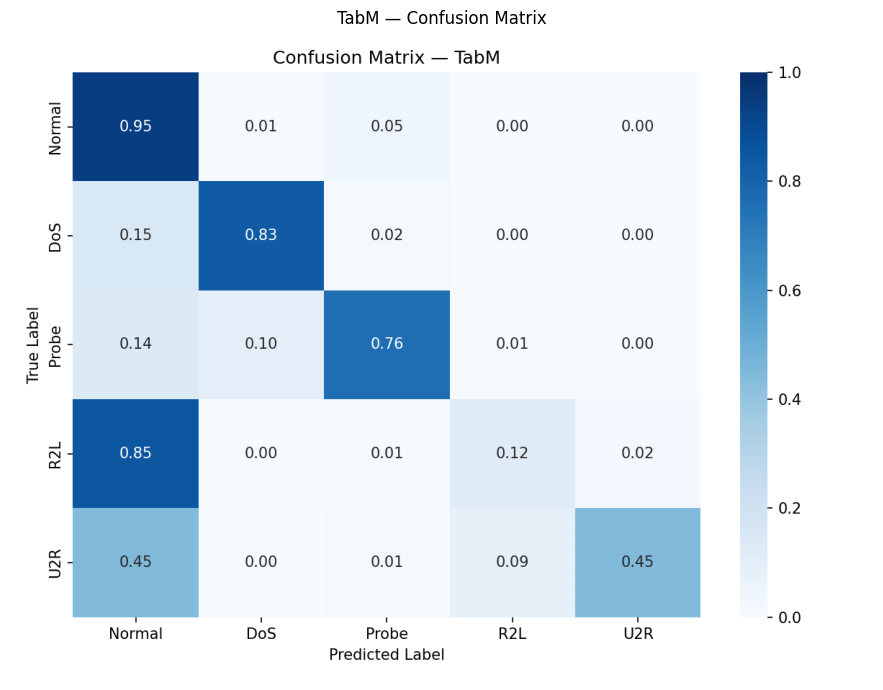

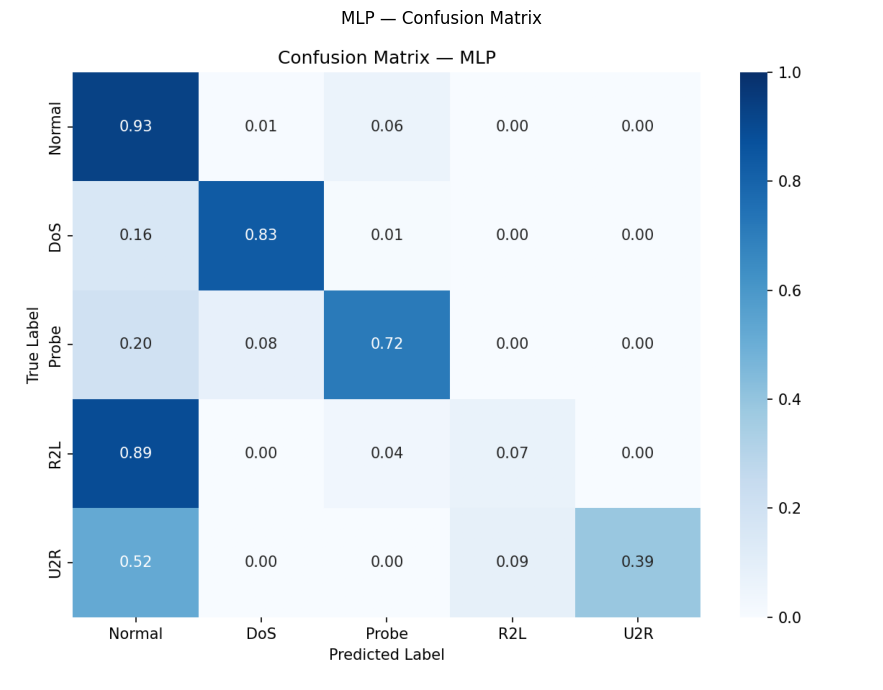

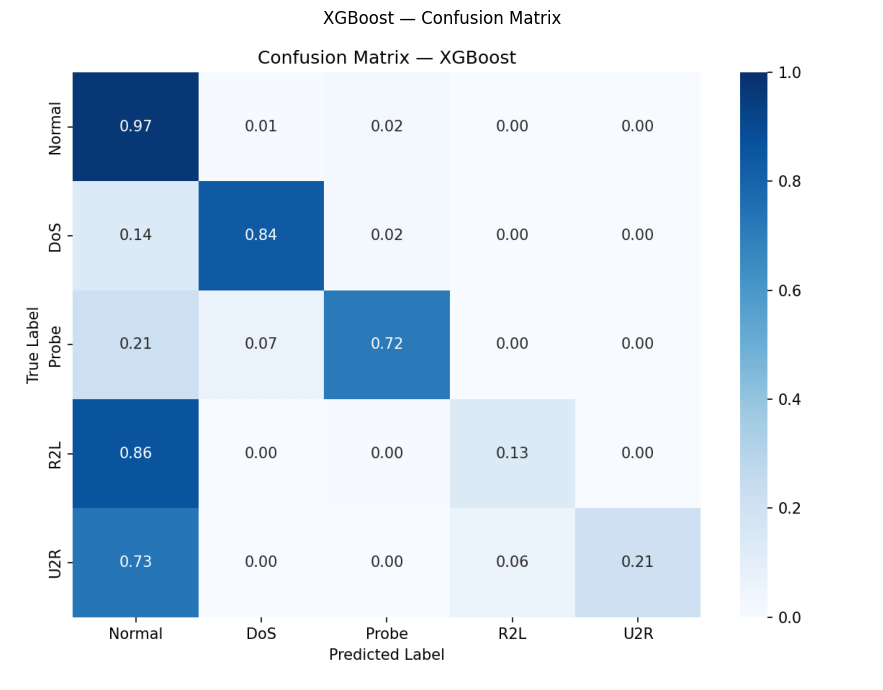

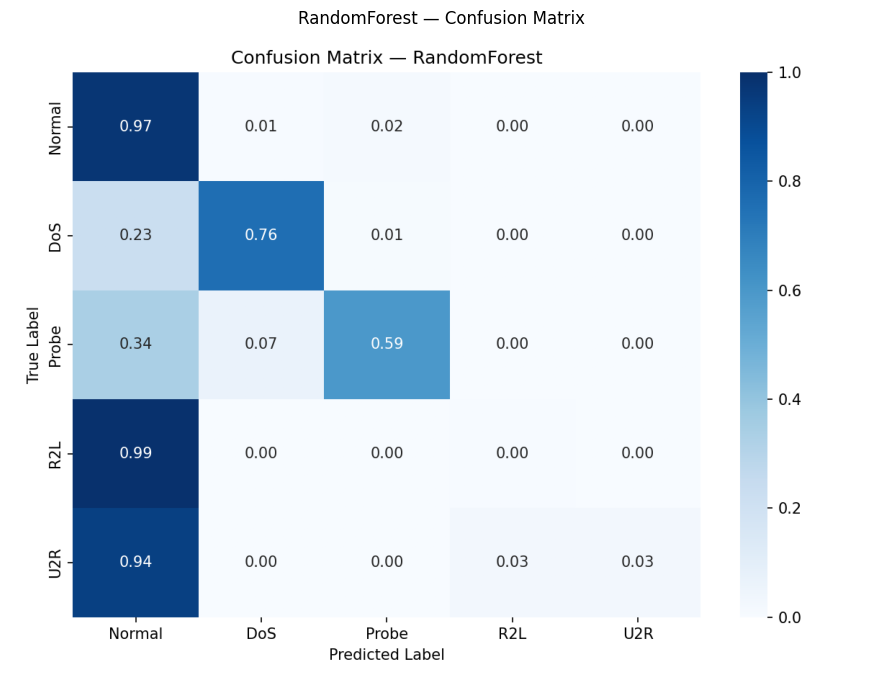

In [14]:
# Display confusion matrices for all four models
for model_name in ['TabM', 'MLP', 'XGBoost', 'RandomForest']:
    show_image(
        f'results/{model_name}_confusion_matrix.png',
        f'{model_name} — Confusion Matrix'
    )

## Cell 12 — Results Discussion

### Key findings to look for

1. **Accuracy vs F1 (macro):** All models tend to achieve high accuracy because Normal and DoS 
   dominate the test set. Macro F1 is the more meaningful metric — it exposes how well each 
   model detects the rare R2L and U2R classes.

2. **TabM vs MLP:** Both have identical model capacity (3 × 256). TabM should score higher on 
   macro F1, demonstrating that BatchEnsemble prediction averaging — not additional parameters — 
   drives the improvement.

3. **TabM vs XGBoost:** XGBoost is the canonical tabular ML champion. If TabM achieves 
   competitive macro F1, it validates the ICLR 2025 claim that TabM rivals gradient boosted 
   trees on real-world tabular tasks.

4. **U2R and R2L classes:** These classes have very few test samples (< 200 combined). Even 
   strong models may show near-zero F1 here without special class-balancing strategies — which 
   we deliberately omit to measure raw model capability.

### Expected performance ranges (from the spec)

| Model | Accuracy | F1 (macro) |
|-------|----------|------------|
| TabM | 94–97% | 75–85% |
| MLP | 92–95% | 70–78% |
| XGBoost | 97–99% | 80–88% |
| Random Forest | 96–98% | 78–85% |

## Deliverables Summary

After running all cells, the `results/` directory will contain:

```
results/
├── summary_metrics.csv              # Side-by-side metric table
├── TabM_report.txt                  # Full classification report
├── MLP_report.txt
├── XGBoost_report.txt
├── RandomForest_report.txt
├── TabM_confusion_matrix.png
├── MLP_confusion_matrix.png
├── XGBoost_confusion_matrix.png
├── RandomForest_confusion_matrix.png
├── f1_comparison.png
├── overall_metrics_comparison.png
├── tabm_training_loss.png
├── xgb_feature_importance.png
├── tabm_model.pt                    # Saved PyTorch weights
├── mlp_model.joblib
├── xgb_model.joblib
└── rf_model.joblib
```